"""
Model Explainability for the Home Credit Default Risk project.

This notebook explains the trained LightGBM credit-risk model using feature
importance and SHAP values. The aim is to identify the strongest drivers of
predicted default risk and create business-facing interpretability outputs.
"""

In [2]:
from pathlib import Path
import sys

import joblib
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
PROJECT_ROOT = Path.cwd().parents[0] if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.append(str(PROJECT_ROOT))

from src.config import (
    TARGET_COLUMN,
    PROCESSED_DATA_DIR,
    PROCESSED_TRAIN_FILE,
    MODELS_DIR,
    REPORTS_DIR,
    FINAL_MODEL_FILE,
)

from src.train_model import (
    split_features_and_target,
    sanitise_feature_names,
)

from src.explain_model import (
    get_model_feature_importance,
    plot_top_feature_importance,
    calculate_shap_values,
    create_shap_bar_plot,
    create_shap_summary_plot,
    get_mean_absolute_shap_importance,
    explain_single_prediction,
)

/Users/shriyanshnautiyal/Downloads/credit-risk-modelling-home-credit/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 100)

In [5]:
processed_train_path = PROCESSED_DATA_DIR / PROCESSED_TRAIN_FILE
model_path = MODELS_DIR / FINAL_MODEL_FILE

processed_train = pd.read_csv(processed_train_path)
model = joblib.load(model_path)

print("Processed training dataset and final model loaded successfully.")
print(f"Processed train shape: {processed_train.shape}")
print(f"Model path: {model_path}")

Processed training dataset and final model loaded successfully.
Processed train shape: (307511, 620)
Model path: /Users/shriyanshnautiyal/Downloads/credit-risk-modelling-home-credit/models/credit_risk_model.pkl


In [6]:
X, y = split_features_and_target(
    df=processed_train,
    target_column=TARGET_COLUMN,
)

X_numeric = X.select_dtypes(include=["number", "bool"]).copy()
X_numeric = sanitise_feature_names(X_numeric)

if hasattr(model, "feature_name_"):
    X_numeric = X_numeric.reindex(columns=model.feature_name_, fill_value=0)

print(f"Numeric feature matrix shape: {X_numeric.shape}")
print(f"Default rate: {y.mean():.4%}")

Numeric feature matrix shape: (307511, 618)
Default rate: 8.0729%


In [7]:
feature_importance = get_model_feature_importance(
    model=model,
    feature_names=list(X_numeric.columns),
)

feature_importance.head(30)

,feature,importance
0,APP_ANNUITY_TO_CREDIT_RATIO,566
1,EXT_SOURCE_1,499
2,EXT_SOURCE_2,486
3,EXT_SOURCE_3,461
4,AMT_ANNUITY,290
5,DAYS_BIRTH,275
6,DAYS_ID_PUBLISH,271
7,APP_GOODS_PRICE_TO_CREDIT_RATIO,233
8,APP_EMPLOYED_YEARS,208
9,BUREAU_BUREAU_DEBT_TO_CREDIT_RATIO_max,204


In [8]:
REPORTS_DIR.mkdir(parents=True, exist_ok=True)

feature_importance_path = REPORTS_DIR / "feature_importance.csv"
feature_importance.to_csv(feature_importance_path, index=False)

print(f"Feature importance saved to: {feature_importance_path}")

Feature importance saved to: /Users/shriyanshnautiyal/Downloads/credit-risk-modelling-home-credit/reports/feature_importance.csv


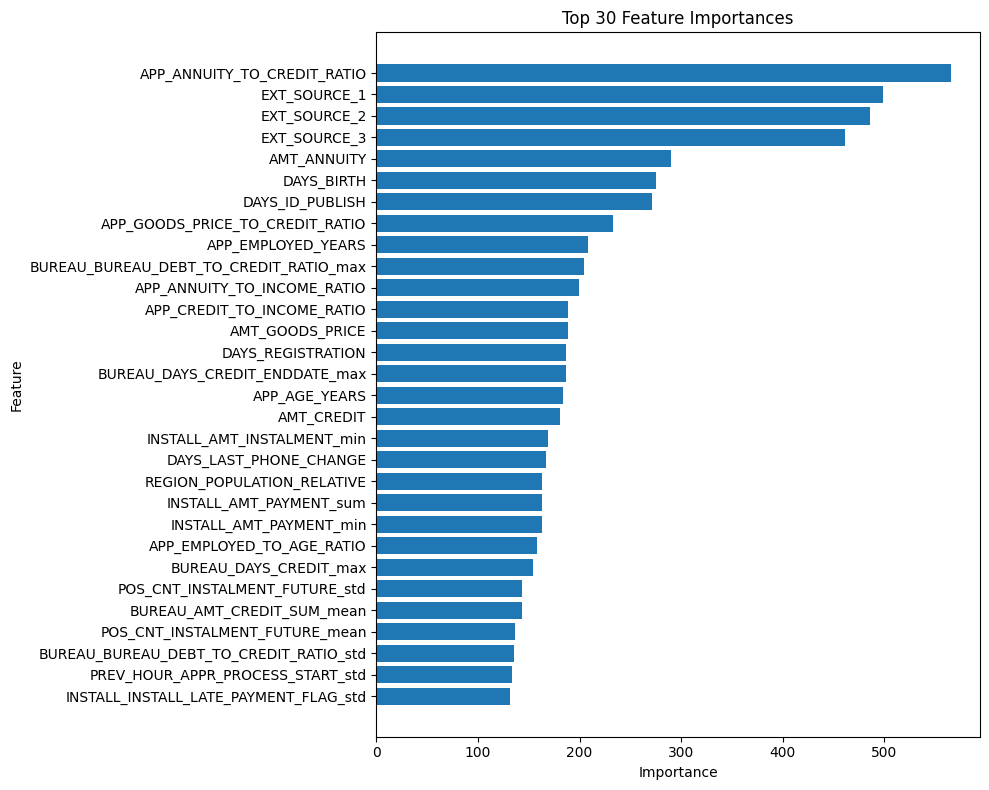

In [9]:
plot_top_feature_importance(
    importance_df=feature_importance,
    top_n=30,
    output_path=REPORTS_DIR / "top_feature_importance.png",
)

In [10]:
X_sample, shap_values = calculate_shap_values(
    model=model,
    X=X_numeric,
    sample_size=5000,
    random_state=42,
)

print("SHAP values calculated successfully.")
print(f"SHAP sample shape: {X_sample.shape}")

SHAP values calculated successfully.
SHAP sample shape: (5000, 618)


/Users/shriyanshnautiyal/Downloads/credit-risk-modelling-home-credit/.venv/lib/python3.12/site-packages/shap/explainers/_tree.py:620: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


In [11]:
shap_importance = get_mean_absolute_shap_importance(
    shap_values=shap_values,
    X_sample=X_sample,
)

shap_importance.head(30)

,feature,mean_absolute_shap_value
0,EXT_SOURCE_2,0.323124
1,EXT_SOURCE_3,0.259258
2,EXT_SOURCE_1,0.146442
3,APP_GOODS_PRICE_TO_CREDIT_RATIO,0.099942
4,AMT_ANNUITY,0.094682
5,BUREAU_BUREAU_DEBT_TO_CREDIT_RATIO_max,0.089686
6,APP_ANNUITY_TO_CREDIT_RATIO,0.087431
7,APP_EMPLOYED_YEARS,0.084029
8,NAME_FAMILY_STATUS_Married,0.065912
9,CODE_GENDER_F,0.063338


In [12]:
shap_importance_path = REPORTS_DIR / "shap_importance.csv"
shap_importance.to_csv(shap_importance_path, index=False)

print(f"SHAP importance saved to: {shap_importance_path}")

SHAP importance saved to: /Users/shriyanshnautiyal/Downloads/credit-risk-modelling-home-credit/reports/shap_importance.csv


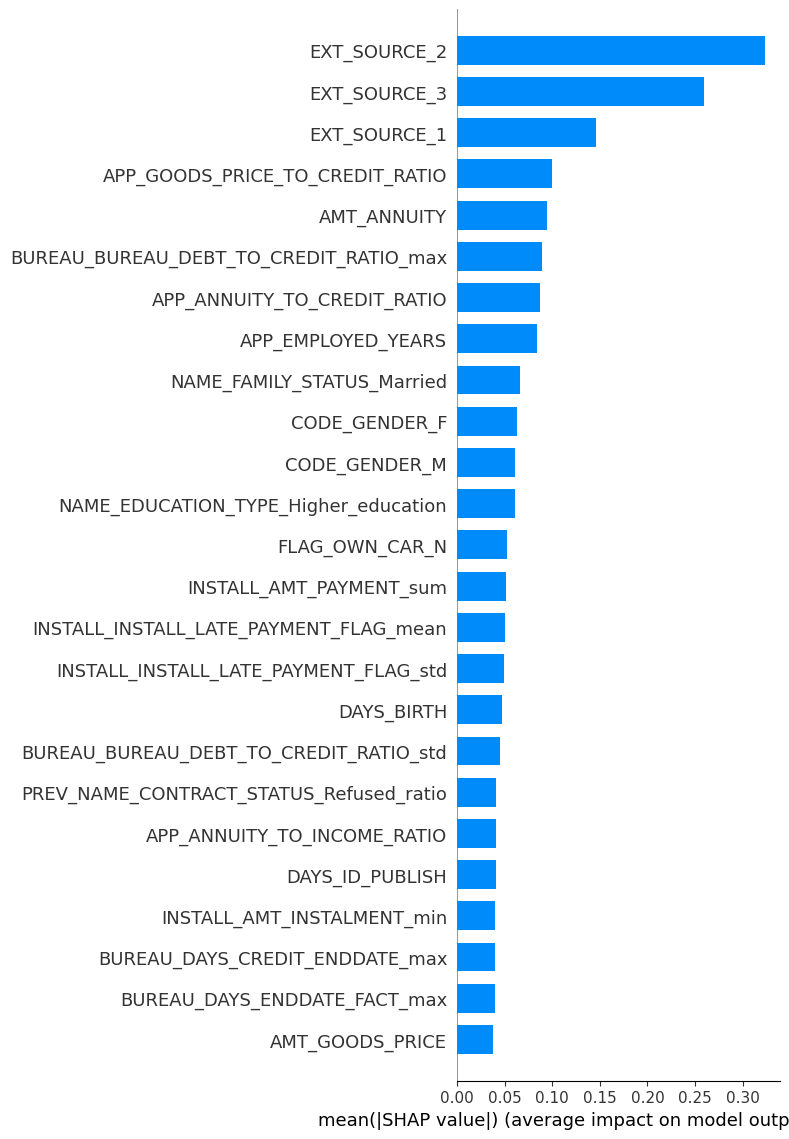

In [13]:
create_shap_bar_plot(
    shap_values=shap_values,
    X_sample=X_sample,
    max_display=25,
    output_path=REPORTS_DIR / "shap_bar_plot.png",
)

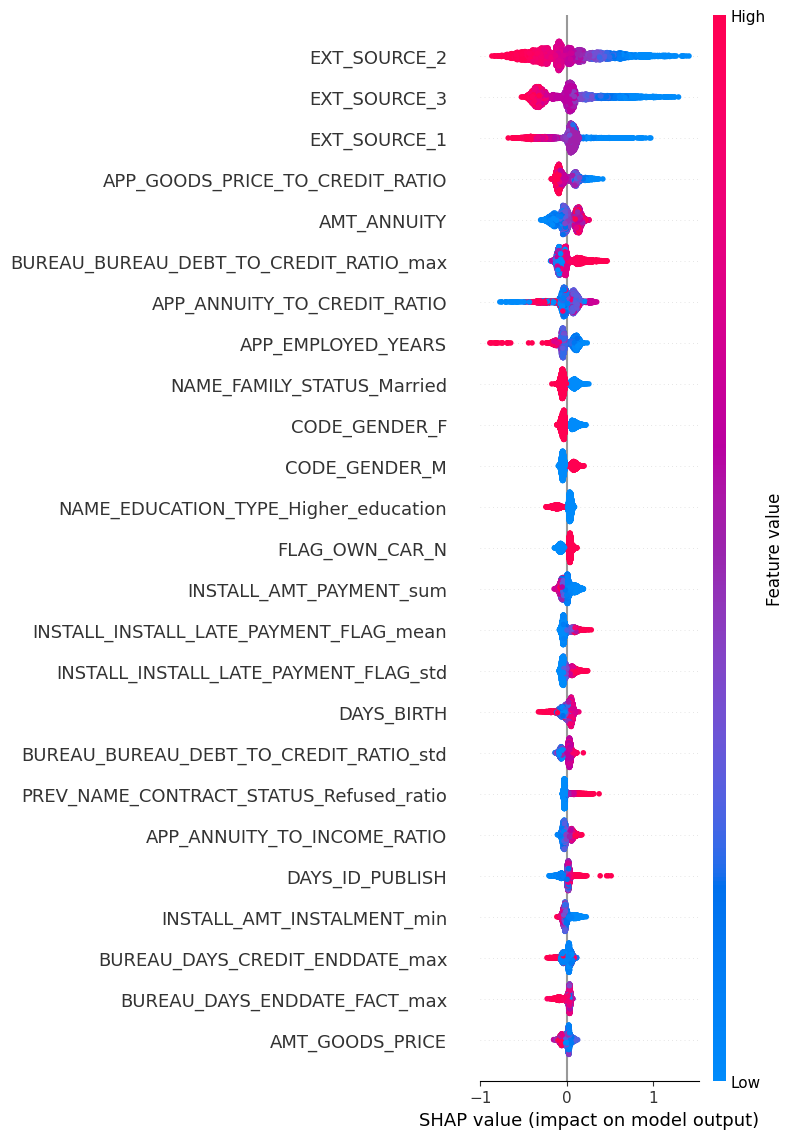

In [14]:
create_shap_summary_plot(
    shap_values=shap_values,
    X_sample=X_sample,
    max_display=25,
    output_path=REPORTS_DIR / "shap_summary_plot.png",
)

In [15]:
highest_risk_position = int(model.predict_proba(X_numeric)[:, 1].argmax())
highest_risk_index = int(X_numeric.index[highest_risk_position])

single_prediction_explanation = explain_single_prediction(
    model=model,
    X=X_numeric,
    applicant_index=highest_risk_index,
    top_n=15,
)

single_prediction_explanation

/Users/shriyanshnautiyal/Downloads/credit-risk-modelling-home-credit/.venv/lib/python3.12/site-packages/shap/explainers/_tree.py:620: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


,feature,feature_value,shap_value,absolute_shap_value
0,EXT_SOURCE_2,0.000558,1.000258,1.000258
1,EXT_SOURCE_3,0.340906,0.200153,0.200153
2,PREV_NAME_CONTRACT_STATUS_Refused_ratio,0.823529,0.184303,0.184303
3,BUREAU_CREDIT_TYPE_Microloan_ratio,1.0,0.176904,0.176904
4,INSTALL_INSTALL_LATE_PAYMENT_FLAG_mean,0.478261,0.118647,0.118647
5,INSTALL_INSTALL_LATE_PAYMENT_FLAG_std,0.510754,0.110564,0.110564
6,EXT_SOURCE_1,0.506155,0.094558,0.094558
7,APP_ANNUITY_TO_CREDIT_RATIO,0.092073,0.087608,0.087608
8,AMT_ANNUITY,33597.0,0.086441,0.086441
9,INSTALL_DAYS_ENTRY_PAYMENT_mean,-380.913043,0.073501,0.073501


In [16]:
single_prediction_explanation.to_csv(
    REPORTS_DIR / "single_high_risk_applicant_explanation.csv",
    index=False,
)

print("Single applicant explanation saved successfully.")

Single applicant explanation saved successfully.


In [17]:
explainability_summary = pd.DataFrame(
    {
        "metric": [
            "model_file",
            "feature_count",
            "shap_sample_size",
            "top_feature_by_model_importance",
            "top_feature_by_shap_importance",
        ],
        "value": [
            str(model_path),
            X_numeric.shape[1],
            X_sample.shape[0],
            feature_importance.iloc[0]["feature"],
            shap_importance.iloc[0]["feature"],
        ],
    }
)

explainability_summary

,metric,value
0,model_file,/Users/shriyanshnautiyal/Downloads/credit-risk...
1,feature_count,618
2,shap_sample_size,5000
3,top_feature_by_model_importance,APP_ANNUITY_TO_CREDIT_RATIO
4,top_feature_by_shap_importance,EXT_SOURCE_2


In [18]:
explainability_summary.to_csv(
    REPORTS_DIR / "explainability_summary.csv",
    index=False,
)

print("Explainability outputs saved successfully.")

Explainability outputs saved successfully.
